In [5]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time


In [8]:


df = pd.read_pickle('../../data/processed/06_cleaned_master_data.pkl')


In [ ]:
print(df.columns.tolist())
print(df[['distance','distance_km_koordinaten']].head(1000))

# Prüfen welche Koordinaten keinen Sinn machen distance (Etappe - Luftlinie Start und Zielkoordinaten) Sollte nicht unter 0 sein, da Etappen ja länger als Luftlinie

df['distance_diff_raw'] = df['distance'] - df['distance_km_koordinaten']
invalid_rows_count = (df['distance_diff_raw'] < 0).sum()
stages_with_errors = df[df['distance_diff_raw'] < 0].groupby(['race', 'year', 'stage_nr']).size().shape[0]
print(f"Anzahl fehlerhafter Datensätze (Fahrer-Zeilen): {invalid_rows_count}")
print(f"Anzahl betroffener Etappen: {stages_with_errors}")


# Somit 191 Etappen betroffen
# Visualisierung der Verteilung


['race', 'year', 'url', 'rank', 'rider_url', 'time_gap', 'birthdate', 'height', 'image_url', 'name', 'nationality', 'place_of_birth', 'points_per_season_history', 'season_results', 'teams_history', 'weight', 'url_name', 'grand_tour_history', 'departure', 'arrival', 'distance', 'vertical_meters', 'profile_score', 'won_how', 'avg_speed', 'race_ranking', 'one_day_races', 'gc', 'time_trial', 'sprint', 'climber', 'hills', 0, 'stage_nr', 'date', 'departure_lat', 'departure_lon', 'arrival_lat', 'arrival_lon', 'distance_km_koordinaten', 'distance_diff', 'distance_diff_raw']
     distance  distance_km_koordinaten
0        19.0                14.741875
1        19.0                14.741875
2        19.0                14.741875
3        19.0                14.741875
4        19.0                14.741875
..        ...                      ...
995     199.0               161.518419
996     199.0               161.518419
997     199.0               161.518419
998     199.0               161.51841

Statistik der fehlerhaften Etappen:
count     191.000000
mean     -609.768657
std       422.245168
min     -1849.118666
25%      -928.158783
50%      -609.944780
75%      -245.516827
max        -1.633515
Name: distance_diff_raw, dtype: float64


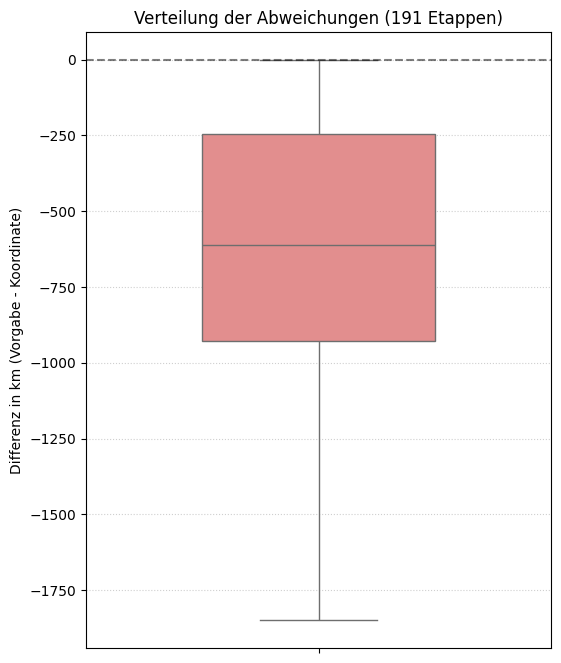

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten auf Etappen-Ebene gruppieren (um Verzerrung durch Fahreranzahl zu vermeiden)
# Wir nehmen nur die Etappen, bei denen die Differenz negativ ist
affected_stages = df.groupby(['race', 'year', 'stage_nr']).agg({
    'distance_diff_raw': 'first'
}).reset_index()

affected_stages = affected_stages[affected_stages['distance_diff_raw'] < 0]

# 2. Boxplot erstellen
plt.figure(figsize=(6, 8))
sns.boxplot(y=affected_stages['distance_diff_raw'], color='lightcoral', width=0.5)

# 3. Optik & Beschriftung
plt.title(f'Verteilung der Abweichungen ({len(affected_stages)} Etappen)')
plt.ylabel('Differenz in km (Vorgabe - Koordinate)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Nulllinie zur Orientierung
plt.grid(axis='y', linestyle=':', alpha=0.6)



# 4. Statistische Kennzahlen ausgeben
print("Statistik der fehlerhaften Etappen:")
print(affected_stages['distance_diff_raw'].describe())

In [ ]:
# Liste der Abweichenden Etappen

target_columns = [
    'race', 'year', 'url', 'departure', 'arrival',
    'departure_lat', 'departure_lon', 'arrival_lat', 'arrival_lon',
    'distance', 'distance_km_koordinaten', 'distance_diff_raw'
]

# 2. Filtern auf die betroffenen Etappen (Differenz < 0)
# Wir nutzen groupby, um pro Etappe nur eine Zeile zu erhalten (die erste gefundene)
problem_stages_df = df[df['distance_diff_raw'] < 0].groupby(['url']).first().reset_index()[target_columns]

# 3. Sortieren nach der größten negativen Abweichung (schlimmste Fehler zuerst)
problem_stages_df = problem_stages_df.sort_values(by='distance_diff_raw', ascending=True)

# 4. Ausgabe der ersten Zeilen zur Kontrolle
print(f"Gefundene Problem-Etappen: {len(problem_stages_df)}")
print(problem_stages_df.head(10))

# Optional: Als CSV speichern für Robert/Lukas zum Checken
problem_stages_df.to_csv('../../data/interim/04-02-01_problem_stages_geodata.csv', index=False)

Gefundene Problem-Etappen: 191
                race  year                                                url  \
146  vuelta-a-espana  2014  https://www.procyclingstats.com/race/vuelta-a-...   
59     giro-d-italia  2020  https://www.procyclingstats.com/race/giro-d-it...   
178  vuelta-a-espana  2022  https://www.procyclingstats.com/race/vuelta-a-...   
47     giro-d-italia  2017  https://www.procyclingstats.com/race/giro-d-it...   
71     giro-d-italia  2022  https://www.procyclingstats.com/race/giro-d-it...   
167  vuelta-a-espana  2020  https://www.procyclingstats.com/race/vuelta-a-...   
186  vuelta-a-espana  2024  https://www.procyclingstats.com/race/vuelta-a-...   
26     giro-d-italia  2011  https://www.procyclingstats.com/race/giro-d-it...   
158  vuelta-a-espana  2017  https://www.procyclingstats.com/race/vuelta-a-...   
64     giro-d-italia  2020  https://www.procyclingstats.com/race/giro-d-it...   

           departure                 arrival  departure_lat  departure_lon  \

In [34]:
# alle Distance 0 erstmal ignorieren
# Puffer von 25km einbauen der als Spielraum gewährt wird


mask = (df['distance'] > 0) & (df['distance_diff_raw'] < -25)
problem_stages_filtered = df[mask]

# 3. Auf Etappen-Ebene reduzieren (Unique URLs)
target_cols = [
    'race', 'year', 'url', 'departure', 'arrival',
    'departure_lat', 'departure_lon', 'arrival_lat', 'arrival_lon',
    'distance', 'distance_km_koordinaten', 'distance_diff_raw'
]

final_export_df = problem_stages_filtered.groupby('url').first().reset_index()[target_cols]

# 4. Speichern als CSV
final_export_df.to_csv('../../data/interim/04-02-02_problem_stages_validation.csv', index=False)

print(f"Es wurden {len(final_export_df)} kritische Etappen identifiziert.")

Es wurden 150 kritische Etappen identifiziert.


In [35]:
print(final_export_df)

                race  year                                                url  \
0      giro-d-italia  2005  https://www.procyclingstats.com/race/giro-d-it...   
1      giro-d-italia  2006  https://www.procyclingstats.com/race/giro-d-it...   
2      giro-d-italia  2007  https://www.procyclingstats.com/race/giro-d-it...   
3      giro-d-italia  2007  https://www.procyclingstats.com/race/giro-d-it...   
4      giro-d-italia  2007  https://www.procyclingstats.com/race/giro-d-it...   
..               ...   ...                                                ...   
145  vuelta-a-espana  2024  https://www.procyclingstats.com/race/vuelta-a-...   
146  vuelta-a-espana  2025  https://www.procyclingstats.com/race/vuelta-a-...   
147  vuelta-a-espana  2025  https://www.procyclingstats.com/race/vuelta-a-...   
148  vuelta-a-espana  2025  https://www.procyclingstats.com/race/vuelta-a-...   
149  vuelta-a-espana  2025  https://www.procyclingstats.com/race/vuelta-a-...   

                           

In [ ]:

geolocator = Nominatim(user_agent="cycling_pro_fixer_v2")

def get_best_coordinates(departure_name, arrival_name, official_distance):
    try:
        # 1. Wir holen uns ALLE möglichen Treffer weltweit für Start und Ziel
        possible_deps = geolocator.geocode(departure_name, exactly_one=False, limit=5)
        possible_arrs = geolocator.geocode(arrival_name, exactly_one=False, limit=5)

        if not possible_deps or not possible_arrs:
            return None

        best_match = None
        min_diff = float('inf')

        # 2. Wir testen jede Kombination (z.B. Lugo/Spanien vs Lugo/Italien)
        for dep in possible_deps:
            for arr in possible_arrs:
                # Berechne Luftlinie für diese Kombination
                calc_dist = geodesic((dep.latitude, dep.longitude), (arr.latitude, arr.longitude)).km

                # Wie weit ist diese Luftlinie von der echten Renndistanz entfernt?
                # Eine gute Luftlinie sollte immer etwas KÜRZER sein als die Straße (ca. 10-30%)
                diff = official_distance - calc_dist

                # Wir suchen die Kombination, die eine positive Differenz hat (Straße > Luftlinie)

                if 0 < diff < min_diff:
                    min_diff = diff
                    best_match = (dep.latitude, dep.longitude, arr.latitude, arr.longitude)

        return best_match
    except:
        return None

# 3. Schleife über deine 150 Problem-Etappen
print("Starte Korrektur...")
for idx, row in final_export_df.iterrows():
    # Wir übergeben die Distanz aus der aktuellen Zeile (row['distance'])
    result = get_best_coordinates(row['departure'], row['arrival'], row['distance'])

    if result:
        final_export_df.at[idx, 'departure_lat_neu'] = result[0]
        final_export_df.at[idx, 'departure_lon_neu'] = result[1]
        final_export_df.at[idx, 'arrival_lat_neu'] = result[2]
        final_export_df.at[idx, 'arrival_lon_neu'] = result[3]

        # Berechnung der neuen Differenz für das Feedback im Terminal
        dist_neu = geodesic((result[0], result[1]), (result[2], result[3])).km
        diff_neu = row['distance'] - dist_neu

        print(f"✅ Gelöst: {row['departure']} -> {row['arrival']} (Diff neu: {diff_neu:.1f} km)")
    else:
        print(f"❌ Keine plausible Kombination gefunden für: {row['departure']} - {row['arrival']}")

    # API-Pause (Nominatim erlaubt max. 1 Request pro Sekunde)
    time.sleep(1.2)

print("\n--- Fertig! ---")

Starte Korrektur...
✅ Gelöst: Celano -> L'Aquila (Diff neu: 191.2 km)
✅ Gelöst: Aosta -> Domodossola (Diff neu: 136.7 km)
✅ Gelöst: Tempio Pausania -> Bosa (Diff neu: 121.9 km)
✅ Gelöst: Bardolino -> Verona (Diff neu: 17.3 km)
✅ Gelöst: Salerno -> Montevergine di Mercogliano (Diff neu: 78.9 km)
✅ Gelöst: Tivoli -> Spoleto (Diff neu: 92.9 km)
✅ Gelöst: Spoleto -> Scarperia (Diff neu: 74.5 km)
❌ Keine plausible Kombination gefunden für: Verona - Alpe di Pampeago - Val di Fiemme
✅ Gelöst: Rovetta -> Tirano (Diff neu: 194.6 km)
✅ Gelöst: Rivisondoli -> Tivoli (Diff neu: 102.3 km)
❌ Keine plausible Kombination gefunden für: Pergola - Monte Petrano
❌ Keine plausible Kombination gefunden für: Chieti - Blockhaus
❌ Keine plausible Kombination gefunden für: Napoli - Anagni
❌ Keine plausible Kombination gefunden für: Padova - San Martino di Castrozza
❌ Keine plausible Kombination gefunden für: Lucera - L'Aquila
❌ Keine plausible Kombination gefunden für: Chianciano Terme - Terminillo
❌ Keine plau

In [38]:
final_export_df.to_csv("../../data/interim/04-02-03_problem_stages_validation.csv", index=False)

# im nächsten Schritt bleibt nur noch die händische Anpassung der Routen
# wird in der Csv angepasst


In [6]:
# Test ob noch kritische Geo Daten vorhanden sind
# 1. Daten laden
file_path = '../../data/interim/04-02-03_problem_stages_validation.csv'
df_korrektur = pd.read_csv(file_path)


# entfernen Kommas am Ende von Strings und konvertieren zu floats
for col in ['departure_lat_neu', 'departure_lon_neu', 'arrival_lat_neu', 'arrival_lon_neu']:
    if col in df_korrektur.columns:
        # Falls es Strings sind: Kommas entfernen. Falls es schon Zahlen sind: lassen.
        df_korrektur[col] = df_korrektur[col].astype(str).str.replace(',', '').replace('nan', None)
        df_korrektur[col] = pd.to_numeric(df_korrektur[col], errors='coerce')

# Neuberechnung
def calc_new_dist(row):
    # Prüfen, ob alle 4 Koordinaten vorhanden und valide Zahlen sind
    coords = [row['departure_lat_neu'], row['departure_lon_neu'],
              row['arrival_lat_neu'], row['arrival_lon_neu']]

    if all(pd.notna(x) for x in coords):
        try:
            start = (float(row['departure_lat_neu']), float(row['departure_lon_neu']))
            end = (float(row['arrival_lat_neu']), float(row['arrival_lon_neu']))
            return geodesic(start, end).km
        except ValueError:
            return row['distance_km_koordinaten']
    else:
        return row['distance_km_koordinaten']

# Berechnung ausführen
df_korrektur['distance_km_koordinaten_neu'] = df_korrektur.apply(calc_new_dist, axis=1)

# Neue Differenz berechnen
df_korrektur['distance_diff_raw_neu'] = df_korrektur['distance'] - df_korrektur['distance_km_koordinaten_neu']

# 3. Test durchführen
mask_still_critical = (df_korrektur['distance'] > 0) & (df_korrektur['distance_diff_raw_neu'] < -25)
critical_now = df_korrektur[mask_still_critical]

print(f"Ergebnis ---")
print(f"Erfolgreich repariert: {len(df_korrektur) - len(critical_now)}")
print(f"Immer noch kritisch: {len(critical_now)}")


Ergebnis ---
Erfolgreich repariert: 150
Immer noch kritisch: 0


In [9]:
# URLs säubern in beiden DataFrames
df['url'] = df['url'].str.strip()
df_korrektur['url'] = df_korrektur['url'].str.strip()

# Nur die relevanten Korrekturspalten aus der Reparaturliste extrahieren
corrections = df_korrektur[['url', 'departure_lat_neu', 'departure_lon_neu', 'arrival_lat_neu', 'arrival_lon_neu']]

In [10]:
# 1. Merge
df1 = df.merge(corrections, on='url', how='left')

# 2. Werte ersetzen: Wo eine Korrektur vorhanden ist, wird der alte Wert überschrieben
df1['departure_lat'] = df1['departure_lat_neu'].fillna(df1['departure_lat'])
df1['departure_lon'] = df1['departure_lon_neu'].fillna(df1['departure_lon'])
df1['arrival_lat'] = df1['arrival_lat_neu'].fillna(df1['arrival_lat'])
df1['arrival_lon'] = df1['arrival_lon_neu'].fillna(df1['arrival_lon'])

# 3. Die _neu Spalten direkt wieder löschen, damit sie nicht stören
df1.drop(columns=['departure_lat_neu', 'departure_lon_neu', 'arrival_lat_neu', 'arrival_lon_neu'], inplace=True)

In [11]:
# Die Funktion zur Distanzberechnung (nutze hier deine vorhandene Funktion oder diesen Einzeiler)
def get_dist(row):
    try:
        return geodesic((row['departure_lat'], row['departure_lon']),
                        (row['arrival_lat'], row['arrival_lon'])).km
    except:
        return np.nan

print("Berechne globale Distanzen neu...")
df1['distance_km_koordinaten'] = df1.apply(get_dist, axis=1)

# Differenz neu berechnen
df1['distance_diff_raw'] = df1['distance'] - df1['distance_km_koordinaten']

Berechne globale Distanzen neu...


In [ ]:
# 1. Neuberechnung der Differenz im Haupt-df (wichtig nach dem Merge!)
df1['distance_diff_raw'] = df1['distance'] - df1['distance_km_koordinaten']

affected_stages_neu = df1.groupby('url').agg({
    'distance_diff_raw': 'first'
}).reset_index()

# Nur die negativen Differenzen inkl 25km Spielraum für den Boxplot
mask_final_problems = (df1['distance'] > 0) & (df1['distance_diff_raw'] < -25)
df_final_problems = df1[mask_final_problems].groupby('url').first().reset_index()


print(f"Übrigen problematischen Stages: {len(df_final_problems)}")



print(df_final_problems['distance_diff_raw'].min())


NameError: name 'df1' is not defined

In [13]:
df1.to_pickle('../../data/processed/07_cleaned_master_data.pkl')